In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

### Imports

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import torchvision.utils as vutils
import torch.optim as optim
from tqdm import tqdm

import os
import random
import matplotlib.pyplot as plt
import pandas as pd

### Helper Functions

In [3]:
def save_image_grid(fake_samples, epoch, path="outputs/"):
    """
        Saves a grid of generated images to disk.
        fake_samples: (B, 1, H, W) tensor in [-1, 1]
    """

    os.makedirs(path, exist_ok=True)

    # denormalise for display
    fake_samples = (fake_samples + 1) / 2

    grid = vutils.make_grid(fake_samples, nrow=8, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(grid_np)
    plt.axis("off")
    plt.title(f"Epoch {epoch}")
    plt.tight_layout()
    plt.savefig(os.path.join(path, f"epoch_{epoch:03d}.png"), dpi=100)
    plt.close()

def plot_loss_curve(loss_G, loss_D, path="outputs/"):
    """
        Saves G and D loss curves across epochs.
    """
    os.makedirs(path, exist_ok=True)

    plt.figure(figsize=(10, 4))
    plt.plot(loss_G, label="Generator Loss", color="steelblue")
    plt.plot(loss_D, label="Discriminator Loss", color="tomato")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(path, "loss_curve.png"), dpi=100)
    plt.close()

def load_and_display_progression(output_dir, epochs):
    """
        Notebook-only function.
        Loads saved grids from disk and plots them side by side for visual progression.
        epochs: e.g. [1, 5, 10, 25, 50]
    """
    fig, axes = plt.subplots(1, len(epochs), figsize=(4 * len(epochs), 4))

    for ax, epoch in zip(axes, epochs):
        img_path = os.path.join(output_dir, f"epoch_{epoch:03d}.png")
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.suptitle("GAN Progression", fontsize=14)
    plt.tight_layout()
    plt.show()

### Model

In [8]:
NUM_CLASSES = 5

def weight_init(m):
    classname = m.__class__.__name__

    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, z_dim=100, features_g=64, num_classes=NUM_CLASSES):
        super().__init__()

        # projects label vector → (B, num_classes, 1, 1)
        # so it can be concatenated with z on channel dim
        self.label_embedding = nn.Sequential(
            nn.Linear(num_classes, num_classes),
            nn.ReLU()
        )

        self.net = nn.Sequential(
            self._block(z_dim + num_classes, features_g * 8, kernel=4, stride=1, padding=0),
            self._block(features_g * 8, features_g * 4, kernel=4, stride=2, padding=1),
            self._block(features_g * 4, features_g * 2, kernel=4, stride=2, padding=1),
            self._block(features_g * 2, features_g,     kernel=4, stride=2, padding=1),
            nn.ConvTranspose2d(features_g, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def _block(self, in_channels, out_channels, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, labels):
        emb = self.label_embedding(labels) # (B, num_classes)
        emb = emb.unsqueeze(-1).unsqueeze(-1) # (B, num_classes, 1, 1)
        x = torch.cat([x, emb], dim=1) # (B, z_dim + num_classes, 1, 1)
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self, features_d=64, num_classes=NUM_CLASSES):
        super().__init__()

        # projects label vector → (B, num_classes, 64, 64)
        # tiled spatially to match image dims for concat on channel dim
        self.label_embedding = nn.Sequential(
            nn.Linear(num_classes, 64 * 64),
            nn.ReLU()
        )

        # first conv takes 3 + num_classes input channels
        self.net = nn.Sequential(
            # no BatchNorm on input
            nn.Conv2d(3 + num_classes, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            self._block(features_d,     features_d * 2, kernel=4, stride=2, padding=1),
            self._block(features_d * 2, features_d * 4, kernel=4, stride=2, padding=1),
            self._block(features_d * 4, features_d * 8, kernel=4, stride=2, padding=1),

            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def _block(self, in_channels, out_channels, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x, labels):
        emb = self.label_embedding(labels) # (B, 64 * 64)
        emb = emb.view(x.size(0), 1, 64, 64) # (B, 1, 64, 64)
        emb = emb.expand(-1, NUM_CLASSES, -1, -1) # (B, num_classes, 64, 64)
        x = torch.cat([x, emb], dim=1) # (B, 3 + num_classes, 64, 64)
        return self.net(x).view(x.size(0), -1) # (B, 1)


### Dataset & DataLoader

In [9]:
SELECTED_ATTRS = [
    "Smiling", 
    "Male", 
    "Young", 
    "Eyeglasses", 
    "Black_Hair",
]

def get_celeba_loader(
    root,
    image_size,
    batch_size,
    num_workers=0,
    max_samples=20000
):
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    full_dataset = datasets.ImageFolder(root=root, transform=transform)

    indices = random.sample(range(len(full_dataset)), min(max_samples, len(full_dataset)))
    dataset = Subset(full_dataset, indices)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True
    )

def get_tensor_loader(pt_path, batch_size):
    tensor = torch.load(pt_path, weights_only=True)
    dataset = TensorDataset(tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=True
    )

class FakeDataset(Dataset):
    def __init__(self, num_samples=1000, image_size=64, num_classes=5):
        super().__init__()

        self.num_samples = num_samples
        self.image_size = image_size
        self.num_classes = num_classes

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image = torch.randn(3, self.image_size, self.image_size)
        labels = torch.randint(0, 2, (self.num_classes,)).float()

        return image, labels 


def get_fake_loader(batch_size, image_size=64, num_classes=5):
    dataset = FakeDataset(num_samples=1000, image_size=image_size, num_classes=num_classes)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

def get_cgan_tensor_loader(pt_path, attr_csv, batch_size):
    images = torch.load(pt_path, weights_only=True) # (50000, 3, 64, 64)
    N = images.shape[0]

    df = pd.read_csv(attr_csv)

    df = df[SELECTED_ATTRS].iloc[:N].replace(-1, 0)
    labels = torch.tensor(df.values, dtype=torch.float32) # (50000, 5)

    print(f"Images: {images.shape}, Labels: {labels.shape}")

    dataset = TensorDataset(images, labels)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )


### Training

In [10]:
# hyperparameters
NUM_CLASSES = 5
IMAGE_SIZE = 64
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LR = 2e-4
Z_DIM = 100
FEATURES_G = 64
FEATURES_D = 64
IMAGE_DIM = 64 * 64 * 3 # 12288
NUM_EPOCHS = 50
SAVE_EPOCHS = [1, 5, 10, 25, 50]
IS_KAGGLE = torch.cuda.is_available()
PT_PATH = "/kaggle/input/datasets/kaushalvaid/celegan-all-phases/celeba_64x64_hr.pt"
ATTR_CSV = "/kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv"

def train():
    # data
    if IS_KAGGLE and PT_PATH:
        loader = get_cgan_tensor_loader(
            pt_path=PT_PATH, 
            attr_csv=ATTR_CSV, 
            batch_size=BATCH_SIZE
        )
    else:
        loader = get_fake_loader(batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)

    # model
    D = Discriminator(features_d=FEATURES_D, num_classes=NUM_CLASSES).to(DEVICE)
    G = Generator(z_dim=Z_DIM, features_g=FEATURES_G, num_classes=NUM_CLASSES).to(DEVICE)
    D.apply(weight_init)
    G.apply(weight_init)

    # loss and optims
    criterion = nn.BCELoss()
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

    # fixed noise
    fixed_noise = torch.randn(64, Z_DIM, 1, 1).to(DEVICE)

    fixed_labels = torch.zeros(64, NUM_CLASSES).to(DEVICE)

    # row grouping to show different attribute
    # rows 0-7:   Smiling only
    fixed_labels[0:8,  0] = 1
    # rows 8-15:  Male only  
    fixed_labels[8:16, 1] = 1
    # rows 16-23: Young only
    fixed_labels[16:24, 2] = 1
    # rows 24-31: Eyeglasses only
    fixed_labels[24:32, 3] = 1
    # rows 32-39: Black Hair only
    fixed_labels[32:40, 4] = 1
    # rows 40-63: no condition active (baseline)

    loss_G_history = []
    loss_D_history = []

    # training
    print("--------------- Starting training ---------------")

    for epoch in range(1, NUM_EPOCHS+1):
        loss_G_epoch = 0.0
        loss_D_epoch = 0.0

        for batch_idx, (real, labels) in enumerate(tqdm(loader, desc=f"Epoch [{epoch}/{NUM_EPOCHS}]", leave=True)):
            
            real = real.to(DEVICE) # shape stays (B, 3, 64, 64)
            labels = labels.to(DEVICE)
            B = real.size(0)

            # train D
            noise = torch.randn(B, Z_DIM, 1, 1).to(DEVICE)
            fake = G(noise, labels).detach()

            real_labels = torch.ones(B, 1).to(DEVICE)
            fake_labels = torch.zeros(B, 1).to(DEVICE)

            loss_D_real = criterion(D(real, labels), real_labels)
            loss_D_fake = criterion(D(fake, labels), fake_labels)

            loss_D = loss_D_fake + loss_D_real

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # train G
            noise = torch.randn(B, Z_DIM, 1, 1).to(DEVICE)
            fake = G(noise, labels)

            loss_G = criterion(D(fake, labels), real_labels)

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            loss_D_epoch += loss_D.item()
            loss_G_epoch += loss_G.item()

        # end of epoch
        avg_G = loss_G_epoch / len(loader)
        avg_D = loss_D_epoch / len(loader)
        loss_G_history.append(avg_G)
        loss_D_history.append(avg_D)

        print(f"Epoch [{epoch}/{NUM_EPOCHS}] | loss_D: {avg_D:.4f} | loss_G: {avg_G:.4f}")

        if epoch in SAVE_EPOCHS:
            with torch.no_grad():
                sample = G(fixed_noise, fixed_labels)
                save_image_grid(sample, epoch, path="outputs/")

    plot_loss_curve(loss_G_history, loss_D_history, path="outputs/")


# calling train
train()


Images: torch.Size([50000, 3, 64, 64]), Labels: torch.Size([50000, 5])
--------------- Starting training ---------------


Epoch [1/50]: 100%|██████████| 390/390 [01:11<00:00,  5.49it/s]


Epoch [1/50] | loss_D: 0.8015 | loss_G: 5.4380


Epoch [2/50]: 100%|██████████| 390/390 [01:12<00:00,  5.38it/s]


Epoch [2/50] | loss_D: 0.7797 | loss_G: 4.2225


...

Epoch [48/50] | loss_D: 0.4558 | loss_G: 3.3954


Epoch [49/50]: 100%|██████████| 390/390 [01:12<00:00,  5.41it/s]


Epoch [49/50] | loss_D: 0.2514 | loss_G: 3.5921


Epoch [50/50]: 100%|██████████| 390/390 [01:12<00:00,  5.41it/s]


Epoch [50/50] | loss_D: 0.4279 | loss_G: 3.4529


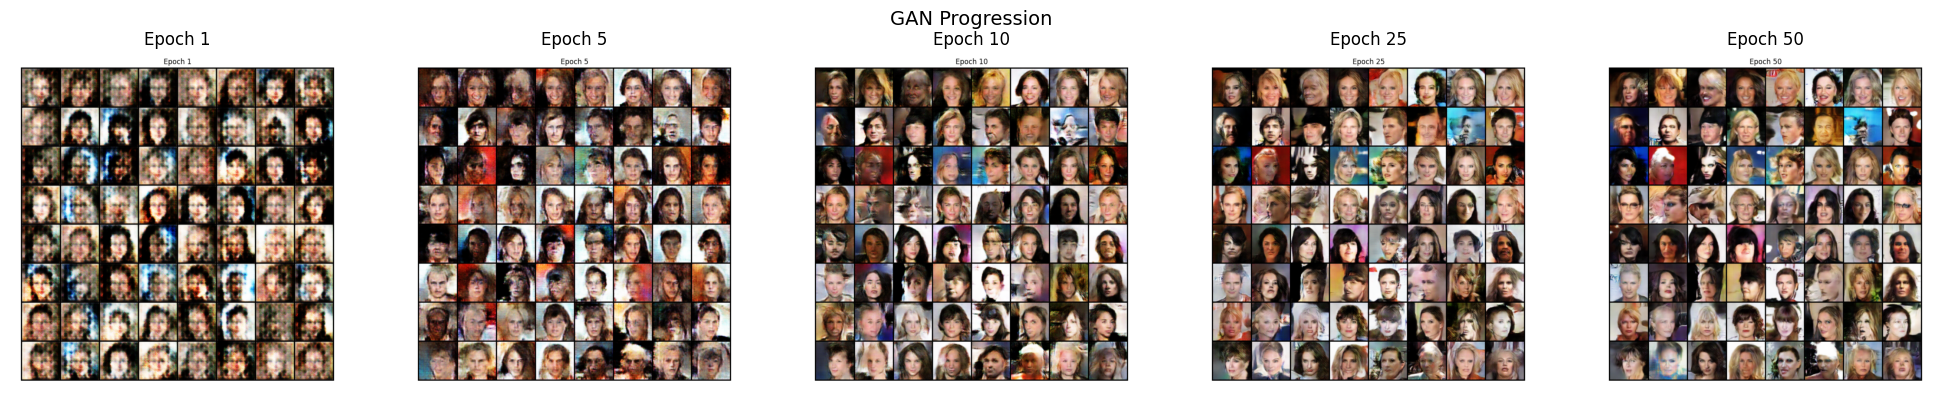

In [11]:
load_and_display_progression(output_dir='/kaggle/working/outputs', epochs=[1, 5, 10, 25, 50])

### Observations

#### What's Working
- **Row 1 (Smiling)**: visibly more teeth, upturned mouths — conditioning took hold.
- **Row 2 (Male)**: broader faces, shorter hair, more masculine features — clearly distinguishable from other rows.
- **Row 4 (Eyeglasses)**: several samples show visible glasses frames — this is the hardest attribute to condition on and it's partially there.
- **Row 3 (Young) and Row 5 (Black Hair)**: less visually distinct — Young is hard because CelebA faces are already mostly young, so D never learned a strong Young vs Not-Young signal. Black Hair shows dark hair in several samples but inconsistently.
- **Image quality**: on par with DCGAN epoch 50 — conditioning added complexity without hurting realism. That's the correct tradeoff.

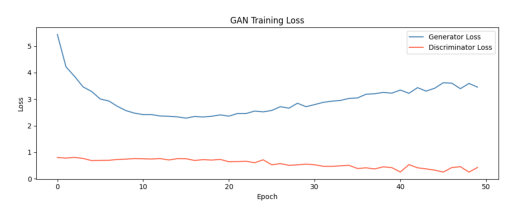

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/working/outputs/loss_curve.png')
plt.imshow(img)
plt.axis('off') # Optional: hides grid lines and pixel counts
plt.show()

### Observations

**loss_D is showing the same late-stage decline as DCGAN** - dropping to 0.25 at epochs 41, 46, 49.

This is the same D-dominance pattern, slightly worse because D now has an easier job: it can reject fakes based on attribute mismatch alone, not just realism.

### Few Improvements

- label smoothing - instead of `real_labels = 1.0`, use `real_labels=0.9` (Makes D's job harder)